# Capstone Assignment - Module I: Predicting some scientific data

**Objective:** Apply machine learning workflows to real scientific  data. You will preprocess data, justify model selection, perform cross-validation, and compare linear models against neural networks.

**Files provided:**
1. `student_data.csv`: Contains the physical features and the target variable (`cfinal`).
2. `evaluation_features.csv`: Contains physical features. The target variable is hidden. You will predict the `cfinal` for these materials and submit them. This will be tested against the expected ones and your score will depend on this.

---
## TEAM MEMBERS
Put here the lastnames, names and emails of your team members. 


---
# Part 1: Data Loading & Preprocessing
1. Load `student_data.csv`.
2. Perform basic Exploratory Data Analysis (EDA). Plot the distribution of `critical_temp`.
3. Check for missing values or extreme anomalies. Be very careful: remove data or if you impute it, justify strongly. 
5. Split this training data into your own local train/test sets (e.g., 80/20) so you can evaluate your models.
6. **Feature Scaling:** Apply appropriate scaling. *Hint: Think carefully about why scaling is absolutely strictly necessary for both Regularized Linear Models and Neural Networks.*

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np
import seaborn as sns
import functions as f

path = './data/student_data.csv'
df = pd.read_csv(path)
print("the size of the dataset is:", np.size(df))
df.head()
print("amount of columns:", df.columns.size)
kurtosis = df.kurtosis(axis=0)
skewness = df.skew(axis=0)
sk_sort, ku_sort = f.sort_values(skewness, kurtosis)
sk_text = ['Columns', 'Skewness Value', 'Skewness of Each Column', 'skewness']
ku_text = ['Columns', 'Kurtosis Value', 'Kurtosis and Skewness of Each Column', 'kurtosis']
f.plot_values(sk_sort.index, sk_sort.values, sk_text)
f.plot_values(ku_sort.index, ku_sort.values, ku_text, color_used='purple')
#f.total_eda_info(df)

meso_kt, lepto_kt, platy_kt = f.classify_kurtosis(ku_sort,epsilon=0.1)
epsilon = 0.1
print("Meso-Kurtosis Columns skewness:")
left_sk_meso, middle_sk_meso, right_sk_meso = f.classify_skewness(meso_kt, epsilon)
print(" ")
print("Lepto-Kurtosis Columns skewness:")
left_sk_lepto, middle_sk_lepto, right_sk_lepto = f.classify_skewness(lepto_kt, epsilon)
print(" ")
print("Platy-Kurtosis Columns skewness:")
left_sk_platy, middle_sk_platy, right_sk_platy = f.classify_skewness(platy_kt, epsilon)
dvalues = df.copy()

dvalues = f.median_imputation(dvalues, meso_kt.index)
dvalues = f.median_imputation(dvalues, lepto_kt.index)
dvalues = f.mean_imputation(dvalues, platy_kt.index)
dvalues.isna().sum()
sns.heatmap(dvalues.isnull(), cbar=False, cmap='viridis')
plt.show()
dkurtosis = dvalues.kurtosis(axis=0)
dskewness = dvalues.skew(axis=0)
dsk_sort, dku_sort = f.sort_values(dskewness, dkurtosis)
sk_text = ['Columns', 'Skewness Value', 'Skewness of Each Column after imputation', 'skewness']
ku_text = ['Columns', 'Kurtosis Value', 'Kurtosis and Skewness of Each Column after imputation', 'kurtosis']
f.plot_values(dsk_sort.index, dsk_sort.values, sk_text)
f.plot_values(dku_sort.index, dku_sort.values, ku_text, color_used='purple')
print(dku_sort.index)

X = dvalues.drop('cfinal', axis=1)
Y = dvalues['cfinal']
# --- Generate the Correlation Matrix ---
corr_matrix = X.corr()
# --- Visualize it with a Heatmap ---
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt=".1f")
plt.title('Full Correlation Matrix (for y and X)')
plt.show()

X_train,X_test,Y_train,Y_test = train_test_split(X,Y, test_size=0.2, random_state=42)
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Part 2: Conceptual Questions & Model Selection

**Answer the following questions below:**
1. Why is this specific problem framed as a **Regression** task?
2. If a colleague suggested using **Logistic Regression** for this task, how would you explain to them mathematically and conceptually why that is the wrong choice?

# Part 3: Linear Regression & Regularization
1. **Unregularized Linear Regression:** Train a standard Ordinary Least Squares (OLS) Linear Regression model. Record its performance (RMSE, MAE, and $R^2$) on your local test set.
2. Analyze the fullfilment of the linear regression model assumptions. 
3. **Regularization (Ridge & Lasso):** 
   * Train a Ridge (L2) and a Lasso (L1) regression model. 
   * Use $k$-fold cross-validation to find the optimal regularization hyperparameters ($\alpha$).
4. **Reflection:** Print the top 5 largest coefficients from your unregularized model and your Ridge model. How drastically did they change? 
5. **Feature Selection:** Did your Lasso model drop any features (set their coefficients to exactly zero)? Look specifically at `lattice_refraction_index` and `mean_quantum_spin_variance`. What does their coefficient in the Lasso model tell you about their physical relevance to superconductivity?
6. **Include your best linear model weights in the submission using `joblib`**

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import scipy.stats as stats
from sklearn.datasets import make_regression #para simular datos 
from sklearn.model_selection import train_test_split #para simular datos
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# Datos simulados --> esto lo hizo gemini porque no sabía cómo hacerlo. Igual se borra cuando ya tengamos los datos reales
# Generamos 1000 muestras, 15 características (5 de ellas no aportan nada al target)
X_dummy, y_dummy = make_regression(n_samples=1000, n_features=15, n_informative=10, noise=0.1, random_state=42)
feature_names = [f'feature_{i}' for i in range(13)] + ['lattice_refraction_index', 'mean_quantum_spin_variance']
X = pd.DataFrame(X_dummy, columns=feature_names)
y = pd.Series(y_dummy, name='cfinal')

# Dividimos y escalamos asumiendo que ya se hizo en la Parte 1
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#-------------------------------------------------------------------------------------------------

### 1. Unregularized Linear Regression
print("Unregularized Linear Regression:")
ols_model = LinearRegression()
ols_model.fit(X_train, y_train)
y_pred_ols = ols_model.predict(X_test)

# Métricas
rmse_ols = np.sqrt(mean_squared_error(y_test, y_pred_ols))
mae_ols = mean_absolute_error(y_test, y_pred_ols)
r2_ols = r2_score(y_test, y_pred_ols)
print(f"RMSE: {rmse_ols:.4f} \n MAE: {mae_ols:.4f} \n R^2: {r2_ols:.4f}\n")




Unregularized Linear Regression:
RMSE: 0.1058 
 MAE: 0.0822 
 R^2: 1.0000



Checking for Linearity and Homoscedasticity...


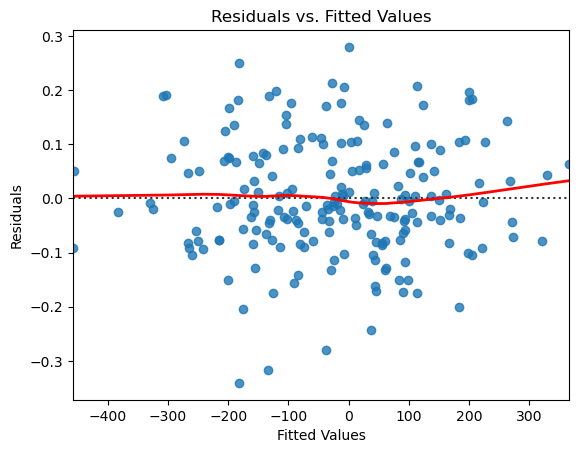

In [44]:
### 2. Model assumptions
#seguimos el mismo procedimiento que el profe pero con scikit-learn en vez de statsmodels (lo cual a veces lo complica más, pero no mucho jajaj)

# 2.1. Linearity: Actual vs Predicted
print("Checking for Linearity and Homoscedasticity...")

fitted = y_pred_ols
residuals = y_test - y_pred_ols

sns.residplot(x=fitted, y=residuals, lowess=True, line_kws={'color': 'red', 'lw': 2})
plt.title('Residuals vs. Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

In [45]:
# 2.2. Homoscedasticity (Statistical Test) 
import statsmodels.stats.api as sms
from statsmodels.tools.tools import add_constant

print("Checking for Homoscedasticity (Breusch-Pagan Test)...")

residuals = y_test - y_pred_ols
exog = add_constant(X_test) #estas cosas son porque en el ejemplo del profe no usa scikit-learn sino statsmodel, entonces tenemos que hacer esto para poder hacer el test de Breusch-Pagan

bp_test = sms.het_breuschpagan(residuals, exog)
print(f"Breusch-Pagan Test p-value: {bp_test[1]:.4f}")
if bp_test[1] > 0.05:
    print("Result: No evidence of heteroscedasticity (Good).")
else:
    print("Result: Evidence of heteroscedasticity found (Bad).")
print("\n" + "="*80 + "\n")

Checking for Homoscedasticity (Breusch-Pagan Test)...
Breusch-Pagan Test p-value: 0.2239
Result: No evidence of heteroscedasticity (Good).




In [46]:
# 2.3. Independence of Residuals (Statistical Test)
from statsmodels.stats.stattools import durbin_watson

print("Checking for Independence of Residuals (Durbin-Watson Test)...")

dw_stat = durbin_watson(residuals) #usamos esta variable que ya calculamos antes por lo mismo de scikit-learn arriba
print(f"Durbin-Watson statistic: {dw_stat:.2f}")
if 1.5 < dw_stat < 2.5:
    print("Result: No significant autocorrelation (Good).")
else:
    print("Result: Potential autocorrelation detected (Bad).")
print("\n" + "="*80 + "\n")

Checking for Independence of Residuals (Durbin-Watson Test)...
Durbin-Watson statistic: 2.16
Result: No significant autocorrelation (Good).




Checking for Normality of Residuals (Q-Q Plot and Jarque-Bera)...


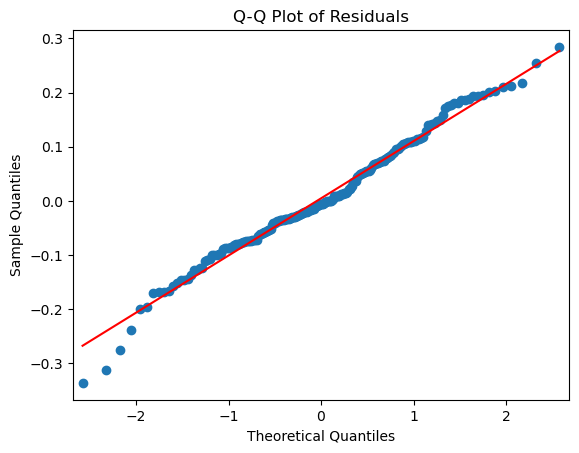

Jarque-Bera test probability: 0.6262272841715374
Result: Residuals appear to be normally distributed (Good).




In [47]:
# 2.4. Normality of Residuals (Statistical Test and Visual)
import statsmodels.api as sm

print("Checking for Normality of Residuals (Q-Q Plot and Jarque-Bera)...")

sm.qqplot(residuals, line='s')
plt.title("Q-Q Plot of Residuals")
plt.show()

#Jarque-Bera Test
jb_stat, jb_prob = stats.jarque_bera(residuals) #nosotros lo hacemos así porque otra vez el profe usó statsmodels jaja y ahí queda guardado en una tabla, acá tenemos que hacerlo a mano usando scipy.stats
#jb_stat es el estadístico y jb_prob es el valor-p

print(f"Jarque-Bera test probability: {jb_prob}")
if jb_prob > 0.05:
    print("Result: Residuals appear to be normally distributed (Good).")
else:
    print("Result: Residuals may not be normally distributed (Bad).")
print("\n" + "="*80 + "\n")

In [48]:
# 2.5. Multicollinearity (VIF Test) 
from statsmodels.stats.outliers_influence import variance_inflation_factor

print("Checking for Multicollinearity (VIF)...")

vif_data = pd.DataFrame()
vif_data["feature"] = X_train.columns# Usamos X_train directamente porque en scikit-learn no le hemos añadido 'const'
vif_data["VIF"] = [variance_inflation_factor(X_train.values, i) for i in range(len(X_train.columns))]

print(vif_data.to_string(index=False))
if all(vif_data["VIF"] < 5):
    print("\nResult: No significant multicollinearity detected (Good).")
else:
    print("\nResult: Potential multicollinearity detected (Bad).")
print("\n" + "="*80 + "\n")

Checking for Multicollinearity (VIF)...
                   feature      VIF
                 feature_0 1.017068
                 feature_1 1.009757
                 feature_2 1.023035
                 feature_3 1.042840
                 feature_4 1.020810
                 feature_5 1.006221
                 feature_6 1.007476
                 feature_7 1.018327
                 feature_8 1.017262
                 feature_9 1.019057
                feature_10 1.017153
                feature_11 1.016084
                feature_12 1.016325
  lattice_refraction_index 1.017384
mean_quantum_spin_variance 1.025261

Result: No significant multicollinearity detected (Good).




In [72]:
### 3. Regularization (Ridge & Lasso)

# Ridge (L2)
ridge_cv = RidgeCV(alphas, cv=5) 
ridge_cv.fit(X_train, y_train)
y_pred_ridge = ridge_cv.predict(X_test)
print(f"Ridge optimal hyperparameter alpha: {ridge_cv.alpha_:.6f}")
print(f"Ridge R^2: {r2_score(y_test, y_pred_ridge):.4f}\n")

# Lasso (L1)
lasso_cv = LassoCV(alphas=alphas, cv=5)
lasso_cv.fit(X_train, y_train)
y_pred_lasso = lasso_cv.predict(X_test)
print(f"Lasso optimal hyperparameter alpha: {lasso_cv.alpha_:.6f}")
print(f"Lasso R^2: {r2_score(y_test, y_pred_lasso):.4f}\n") #con los datos simulados, R^2 es 1 porque es una simulación perfecta

Ridge optimal hyperparameter alpha: 0.000933
Ridge R^2 en test: 1.0000

Lasso optimal hyperparameter alpha: 0.000443
Lasso R^2 en test: 1.0000



In [83]:
### 4. Reflection: Top 5 Coefficients

# Creamos un DataFrame para comparar fácilmente
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'OLS_Coef': np.abs(ols_model.coef_), 
    'Ridge_Coef': np.abs(ridge_cv.coef_),
    'OLS_Coef_Real': ols_model.coef_, 
    'Ridge_Coef_Real': ridge_cv.coef_
})

# Top 5 OLS
top5_ols = coef_df.sort_values(by='OLS_Coef', ascending=False).head(5)
print("Top 5 coeficientes más grandes OLS:")
print(top5_ols[['Feature', 'OLS_Coef_Real']].to_string(index=False), "\n")

# Top 5 Ridge
top5_ridge = coef_df.sort_values(by='Ridge_Coef', ascending=False).head(5)
print("Top 5 coeficientes más grandes Ridge:")
print(top5_ridge[['Feature', 'Ridge_Coef_Real']].to_string(index=False), "\n")

print("How drastically did they change? lo respondemos cuando tengamos los datos reales")

Top 5 coeficientes más grandes OLS:
  Feature  OLS_Coef_Real
feature_1      89.828109
feature_5      84.978693
feature_2      80.292905
feature_9      52.703798
feature_4      38.960636 

Top 5 coeficientes más grandes Ridge:
  Feature  Ridge_Coef_Real
feature_1        89.828001
feature_5        84.978597
feature_2        80.292800
feature_9        52.703737
feature_4        38.960592 

How drastically did they change? lo respondemos cuando tengamos los datos reales


In [97]:
### 5. Feature Selection
noisy_features = ['lattice_refraction_index', 'mean_quantum_spin_variance']

lasso_coefs = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lasso_cv.coef_
})

print("\nCoeficientes asignados por Lasso a las variables raras:")
print(lasso_coefs[lasso_coefs['Feature'].isin(noisy_features)].to_string(index=False)) #el peso que dio Lasso a las variables raras
#está dando un número grande para el mean_quantum_spin_variance, pero podría ser por ser datos simulados

variables_eliminadas = lasso_coefs[lasso_coefs['Coefficient'] == 0]
print(f"\nLasso eliminó {len(variables_eliminadas)} variables, haciendolas exactamente cero.\n")
print(f"What does their coefficient in the Lasso model tell you about their physical relevance to superconductivity?\n Que el coeficiente en Lasso sea igual a cero, indica que al evaluar las variables lattice_refraction_index y mean_quantum_spin_variance, el modelo identificó que carecían de relevancia predictiva real, lo cual nos indica que físicamente no son relevantes para la superconductividad. Por esta razón, para maximizar la eficiencia y minimizar la función de costo, Lasso redujo el valor del coeficiente a 0, eliminándolas del modelo.")
#No sé si esta interpretación cambie con los datos reales, pero creo que se mantiene


Coeficientes asignados por Lasso a las variables raras:
                   Feature  Coefficient
  lattice_refraction_index     0.004316
mean_quantum_spin_variance    38.666751

Lasso eliminó 0 variables, haciendolas exactamente cero.

What does their coefficient in the Lasso model tell you about their physical relevance to superconductivity?
 Que el coeficiente en Lasso sea igual a cero, indica que al evaluar las variables lattice_refraction_index y mean_quantum_spin_variance, el modelo identificó que carecían de relevancia predictiva real, lo cual nos indica que físicamente no son relevantes para la superconductividad. Por esta razón, para maximizar la eficiencia y minimizar la función de costo, Lasso redujo el valor del coeficiente a 0, eliminándolas del modelo.


In [ ]:
### 6. Best linear model weights



# Part 4: Neural Networks
1. **Build a Neural Network:** Implement a feedforward Neural Network (Multi-Layer Perceptron) using `sklearn`, `PyTorch`, or `Keras`.
2. **Cross-Validation/Tuning:** Experiment with the architecture (number of hidden layers, neurons) and learning rate. Use a validation set to prevent overfitting (Early Stopping is highly recommended).
3. **Evaluation:** Evaluate your best Neural Network on your local test set using the same metrics as the linear models (RMSE, MAE, $R^2$). 
4. **Reflection:** Plot the residuals (predicted vs. true values) for both your best Linear model and your Neural Network. In what range does the linear model struggle the most compared to the NN?
5. **Include your best nn weights in the submission using `joblib`**. Describe the arquitecture.

# Part 5: Final Analysis and Exporting Predictions

**Final Analysis:**
Which model performed the best on your local test set? If a physicist asked you *which features* are most important for discovering a new material with this data, which model would you show them and why? Explain the trade-off between interpretability and performance in this context.

**Generate Final Predictions:**
Use your **best overall model** to predict the critical temperatures for the materials in `evaluation_features.csv`. Export your predictions to a CSV file named `my_predictions.csv`. It is just one column. Call it `predicted_cfinal`. 

# Bonus
If you first perform PCA, can you accomplish any dimensionality reduction? are your predictions better? analyze and support your claims.  